# Age Classification - Inference

**Input:** 30,000+ face crops from `/face_crops_aligned/`
**Model:** `models/age_classifier.pth`
**Output:** Classified crops in `/classified/adult/` and `/classified/child/`

## Step 1: Setup

In [1]:
!pip install torch torchvision timm -q

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import timm
import shutil
import json
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from datetime import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using: {device}")

Mounted at /content/drive
✓ Using: cpu


## Step 2: Configuration

In [2]:
BASE_PATH = Path("/content/drive/MyDrive/face_pipeline_project")
MODEL_PATH = BASE_PATH / "models/age_classifier.pth"
FACE_CROPS_FOLDER = BASE_PATH / "face_crops_aligned"
CLASSIFIED_FOLDER = BASE_PATH / "classified"
ADULT_FOLDER = CLASSIFIED_FOLDER / "adult"
CHILD_FOLDER = CLASSIFIED_FOLDER / "child"
METRICS_FOLDER = BASE_PATH / "metrics"
CHECKPOINT_FILE = BASE_PATH / "checkpoint_age_inference.json"

# Create folders
ADULT_FOLDER.mkdir(exist_ok=True, parents=True)
CHILD_FOLDER.mkdir(exist_ok=True, parents=True)
METRICS_FOLDER.mkdir(exist_ok=True, parents=True)

print(f"Model: {MODEL_PATH}")
print(f"Input: {FACE_CROPS_FOLDER}")
print(f"Output: {CLASSIFIED_FOLDER}")

Model: /content/drive/MyDrive/face_pipeline_project/models/age_classifier.pth
Input: /content/drive/MyDrive/face_pipeline_project/face_crops_aligned
Output: /content/drive/MyDrive/face_pipeline_project/classified


## Step 3: Load Model

In [3]:
print("Loading EfficientNet-B0 model...")
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()
print("✓ Model loaded")

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Loading EfficientNet-B0 model...
✓ Model loaded


## Step 4: Checkpoint Functions

In [4]:
def load_checkpoint():
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, 'r') as f:
            cp = json.load(f)
            print(f"✓ Resuming: {len(cp.get('completed_videos', []))} videos done")
            return cp
    return {'completed_videos': [], 'adult': 0, 'child': 0}

def save_checkpoint(cp):
    cp['last_updated'] = datetime.now().isoformat()
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(cp, f, indent=2)

checkpoint = load_checkpoint()

## Step 5: Run Inference

In [5]:
# Get video folders
video_folders = sorted([f for f in FACE_CROPS_FOLDER.iterdir() if f.is_dir()])
completed = set(checkpoint['completed_videos'])
remaining = [v for v in video_folders if v.name not in completed]

print(f"Total videos: {len(video_folders)}")
print(f"Completed: {len(completed)}")
print(f"Remaining: {len(remaining)}")

# Load existing results
results_file = METRICS_FOLDER / "age_classifications_v2.csv"
if results_file.exists():
    all_results = pd.read_csv(results_file).to_dict('records')
else:
    all_results = []

for video_folder in remaining:
    video_name = video_folder.name
    print(f"\n{'='*50}")
    print(f"Processing: {video_name}")
    print(f"{'='*50}")

    # Create output folders
    (ADULT_FOLDER / video_name).mkdir(exist_ok=True)
    (CHILD_FOLDER / video_name).mkdir(exist_ok=True)

    face_files = sorted(list(video_folder.glob("*.jpg")))
    print(f"Faces: {len(face_files)}")

    adult_count = 0
    child_count = 0

    for face_path in tqdm(face_files, desc="Classifying"):
        try:
            # Load and transform
            img = Image.open(face_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(device)

            # Predict
            with torch.no_grad():
                output = model(img_tensor)
                prob = torch.softmax(output, dim=1)
                predicted = output.argmax(dim=1).item()
                confidence = prob[0, predicted].item()

            # Classify: 0=child, 1=adult
            if predicted == 1:
                classification = 'adult'
                dest = ADULT_FOLDER / video_name / face_path.name
                adult_count += 1
            else:
                classification = 'child'
                dest = CHILD_FOLDER / video_name / face_path.name
                child_count += 1

            # Copy file
            shutil.copy(face_path, dest)

            # Log
            all_results.append({
                'video': video_name,
                'face_file': face_path.name,
                'classification': classification,
                'confidence': round(confidence, 3)
            })

        except Exception as e:
            print(f"Error: {face_path.name} - {e}")

    # Update checkpoint
    checkpoint['completed_videos'].append(video_name)
    checkpoint['adult'] += adult_count
    checkpoint['child'] += child_count
    save_checkpoint(checkpoint)

    print(f"✓ Adults: {adult_count} | Children: {child_count}")

    # Save results
    pd.DataFrame(all_results).to_csv(results_file, index=False)

print(f"\n" + "="*50)
print("✅ COMPLETE!")
print(f"Total Adults: {checkpoint['adult']}")
print(f"Total Children: {checkpoint['child']}")
print(f"="*50)

Total videos: 31
Completed: 0
Remaining: 31

Processing: 08.56.26-09.18.33[M][0@0][107006]_ch1
Faces: 557


Classifying: 100%|██████████| 557/557 [01:20<00:00,  6.88it/s]


✓ Adults: 355 | Children: 202

Processing: 09.09.21-09.40.22[M][0@0][49652]_ch1
Faces: 283


Classifying: 100%|██████████| 283/283 [00:35<00:00,  8.07it/s]


✓ Adults: 140 | Children: 143

Processing: 09.14.00-10.18.46[M][0@0][126501]_ch1
Faces: 3709


...

✓ Adults: 155 | Children: 69

Processing: 15.52.42-16.07.48[M][0@0][17210]_ch1
Faces: 756


Classifying: 100%|██████████| 756/756 [01:40<00:00,  7.53it/s]


✓ Adults: 638 | Children: 118

Processing: 16.10.25-16.37.17[M][0@0][123219]_ch1
Faces: 86


Classifying: 100%|██████████| 86/86 [01:04<00:00,  1.34it/s]


✓ Adults: 8 | Children: 78

✅ COMPLETE!
Total Adults: 24093
Total Children: 6726


## Step 6: Summary

In [6]:
# Count classified faces
adult_total = sum(len(list((ADULT_FOLDER / v.name).glob("*.jpg"))) for v in video_folders if (ADULT_FOLDER / v.name).exists())
child_total = sum(len(list((CHILD_FOLDER / v.name).glob("*.jpg"))) for v in video_folders if (CHILD_FOLDER / v.name).exists())

print(f"Classification Summary:")
print(f"  Adults: {adult_total}")
print(f"  Children: {child_total}")
print(f"  Total: {adult_total + child_total}")
print(f"\nChild percentage: {child_total/(adult_total+child_total)*100:.1f}%")

Classification Summary:
  Adults: 24093
  Children: 6726
  Total: 30819

Child percentage: 21.8%


---
## ✅ Done!

**Output:**
- Adults: `/classified/adult/[video]/`
- Children: `/classified/child/[video]/`
- Log: `/metrics/age_classifications_v2.csv`

**Next:** Run Emotion Classification on child faces

In [8]:
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets
import pandas as pd
from pathlib import Path

BASE_PATH = Path("/content/drive/MyDrive/face_pipeline_project")
METRICS_FOLDER = BASE_PATH / "metrics"
GROUND_TRUTH_FOLDER = BASE_PATH / "ground_truth"
CLASSIFIED_FOLDER = BASE_PATH / "classified"

# Load classification results
df = pd.read_csv(METRICS_FOLDER / "age_classifications_v2.csv")

# Sample 100 random for validation
SAMPLE_SIZE = 100
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)

print(f"Total classified: {len(df)}")
print(f"Sample for validation: {len(df_sample)}")

labels = {}
current_idx = [0]
LABELS_FILE = GROUND_TRUTH_FOLDER / "age_validation.csv"

def save_labels():
    df_sample['actual'] = df_sample.index.map(lambda x: labels.get(x, ''))
    df_sample.to_csv(LABELS_FILE, index=False)

def show_face(idx):
    clear_output(wait=True)

    if idx >= len(df_sample):
        save_labels()
        print("✅ DONE!")
        print(f"Labeled: {len(labels)}")
        return

    row = df_sample.iloc[idx]
    folder = CLASSIFIED_FOLDER / row['classification'] / row['video']
    img_path = folder / row['face_file']

    print(f"Image {idx+1}/{len(df_sample)} | Labeled: {len(labels)}")
    print(f"Model says: {row['classification'].upper()} ({row['confidence']:.1%})")

    if img_path.exists():
        display(IPImage(filename=str(img_path)))

    btn_adult = widgets.Button(description="👨 ADULT", button_style='info', layout=widgets.Layout(width='150px', height='50px'))
    btn_child = widgets.Button(description="👶 CHILD", button_style='warning', layout=widgets.Layout(width='150px', height='50px'))
    btn_skip = widgets.Button(description="Skip", layout=widgets.Layout(width='100px'))
    btn_save = widgets.Button(description="💾 Save", button_style='success', layout=widgets.Layout(width='100px'))

    def on_adult(b): labels[idx] = 'adult'; current_idx[0] += 1; show_face(current_idx[0])
    def on_child(b): labels[idx] = 'child'; current_idx[0] += 1; show_face(current_idx[0])
    def on_skip(b): current_idx[0] += 1; show_face(current_idx[0])
    def on_save(b): save_labels(); print(f"💾 Saved {len(labels)} labels")

    btn_adult.on_click(on_adult); btn_child.on_click(on_child)
    btn_skip.on_click(on_skip); btn_save.on_click(on_save)

    display(widgets.HBox([btn_adult, btn_child, btn_skip, btn_save]))

show_face(0)

✅ DONE!
Labeled: 100


Labeled samples: 100


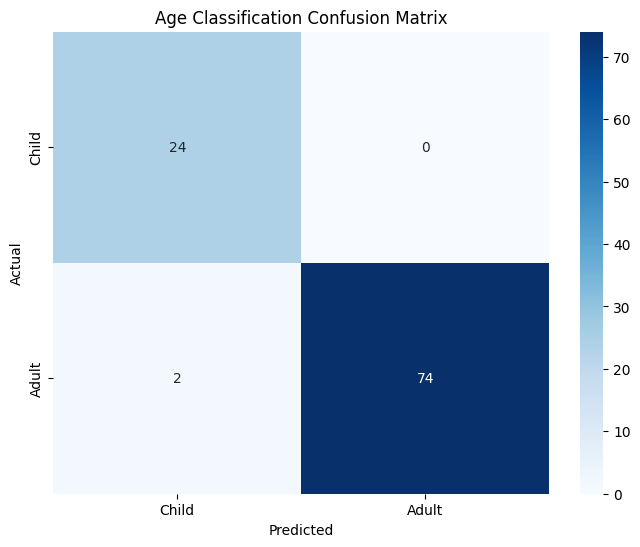


              precision    recall  f1-score   support

       Child       1.00      0.97      0.99        76
       Adult       0.92      1.00      0.96        24

    accuracy                           0.98       100
   macro avg       0.96      0.99      0.97       100
weighted avg       0.98      0.98      0.98       100


Overall Accuracy: 98.0%


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

LABELS_FILE = GROUND_TRUTH_FOLDER / "age_validation.csv"
df_gt = pd.read_csv(LABELS_FILE)

# Filter labeled
df_labeled = df_gt[df_gt['actual'].notna() & (df_gt['actual'] != '')].copy()

print(f"Labeled samples: {len(df_labeled)}")

y_true = df_labeled['actual'].values
y_pred = df_labeled['classification'].values

cm = confusion_matrix(y_true, y_pred, labels=['child', 'adult'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Child', 'Adult'],
            yticklabels=['Child', 'Adult'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Age Classification Confusion Matrix')
plt.savefig(METRICS_FOLDER / "confusion_matrix_age.png", dpi=150)
plt.show()

print("\n" + "="*50)
print(classification_report(y_true, y_pred, target_names=['Child', 'Adult']))

accuracy = (y_true == y_pred).mean()
print(f"\nOverall Accuracy: {accuracy:.1%}")